In [1]:
%matplotlib widget
import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'
import warp as wp; wp.init()

import torch
# from compressibleSPH.gencase import *
from compressibleSPH.sample import generateInitialVariables, SamplingScheme
from compressibleSPH.sampling import  sampleParticles
# from waves.util import plotState, plotInitialState
# from simulation import runSimulation
from compressibleSPH.utils import getCurrentTimestamp
from argparse import ArgumentParser
from compressibleSPH.casefile import argparse_defaults_from_casefile, load_casefile

# from compressibleSPH.systemv3 import WaveSystemStatev3
from compressibleSPH.sample import smoothState
# from compressibleSPH.systemv3 import WaveSystemv3, f_wave_equation
from integrators.integration import *
from compressibleSPH.utils import *
from sphWarpCore import *
# from compressibleSPH.systemv3 import WaveSystemStatev3

from sphWarpCore.radiusSearch.verlet import *
from sphWarpCore.radius import AdjacencyList
from sphWarpCore.operations import *
from sphWarpCore.enumTypes import *

from sphWarpCore import *
# from waves.sampling import sampleParticles
# from compressibleSPH.systemv3 import sampleInitialWaveState
# from compressibleSPH.systemv3 import computeDt
from compressibleSPH.sampling import finalizeWaveSystemSetup
from compressibleSPH.shape_generation import populateSourceObstacleGridsStructured

from compressibleSPH.config import SimulationConfig, CompressibleSPHConfig
from compressibleSPH.caseUtils.sod import *
from compressibleSPH.util import *
from compressibleSPH.schemes import *
from sphWarpCore.diffusion.viscosity import DiffusionParameters

from diffSPH.enums import ViscositySwitch, KernelType
from torch.profiler import profile, record_function, ProfilerActivity
from tqdm.autonotebook import tqdm

Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [2]:
nx = 800
gamma = 5/3
leftState = sodInitialState(1, 1, 0)
rightState = sodInitialState(0.1795, 0.25, 0)
samplingRatio = 1
smoothIC = True
timeLimit = 0.15

L = 2
dim = 1
n_h = 4
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = torch.float32

config = SimulationConfig(
    domain = buildDomainDescription(L, dim, True, device, dtype),
    dim = dim,
    kernel = KernelFunctions.Wendland2,
    targetNeighbors = n_h_to_nH(n_h, dim),
    supportMode = SupportScheme.Gather,
    gradientMode = GradientScheme.Difference,
    laplacianMode = LaplacianScheme.Brookshaw,
    integrationScheme = IntegrationSchemeType.rungeKutta4,
    samplingScheme = SamplingScheme.regular,
    device = device,
    dtype = dtype,
    dt = 1e-3,
    adaptiveDt = False,
    cflFactor=0.3,
)

diffusionParams = DiffusionParameters()
diffusionParams.c_s = 1
diffusionParams.C_l = 1
diffusionParams.C_q = 0
diffusionParams.Cu_l = 1
diffusionParams.Cu_q = 0
diffusionParams.K = 1.0
diffusionParams.thermalConductivity = 0.5
diffusionParams.viscosityTerm = 7
diffusionParams.thermalConducitiyTerm = 9
diffusionParams.scaleBeta = False
diffusionParams.monaghanSwitch = True
diffusionParams.correctXi = True

compressibleSPHConfig = CompressibleSPHConfig(
    gamma = gamma,
    rho0 = leftState.rho,
    diffusionParams = diffusionParams,
)
integrator = getIntegrator(config.integrationScheme)


In [3]:
from compressibleSPH.systems.compressibleMonaghan import CompressibleState
domain = buildDomainDescription(L, dim, True, device, dtype)

particles_ = sampleRegularParticles(nx, domain, config.targetNeighbors)
# domain = buildDomainDescription(domainExtent * 1.5, dim, periodic = periodicDomain, device = device, dtype = dtype)
particles_ = particles_._replace(masses = particles_.masses * compressibleSPHConfig.rho0)


particles = CompressibleState(
    positions = particles_.positions,
    supports = particles_.supports,
    masses = particles_.masses,
    densities = particles_.densities,
    velocities = torch.zeros_like(particles_.positions),
    
    kinds = torch.zeros_like(particles_.positions[:,0], dtype = torch.int32),
    materials = torch.zeros_like(particles_.positions[:,0], dtype = torch.int32),
    UIDs = torch.arange(particles_.positions.shape[0], device = device, dtype = torch.int32),
    UIDcounter = particles_.positions.shape[0],
    
    internalEnergies = None,
    totalEnergies = None,
    entropies = None,
    pressures = None,
    soundspeeds = None,

    divergence=torch.zeros_like(particles_.densities),
    alpha0s= torch.ones_like(particles_.densities),
    alphas= torch.ones_like(particles_.densities),
)

In [4]:
from diffSPH.simple import *
from diffSPH.modules.adaptiveSmoothingASPH import createPsiLUT as createPsiLUT_diffSPH

In [5]:

# from sphWarpCore.kernels.wp_kernel import sphKernel
from diffSPH.kernels import Kernel as diffSPHKernel
from diffSPH.kernels import KernelType

def warpKernelToDiffSPHKernel(
        warpKernel: KernelFunctions
):
    if warpKernel == KernelFunctions.Poly6:
        return KernelType.Poly6
    elif warpKernel == KernelFunctions.CubicSpline:
        return KernelType.CubicSpline
    elif warpKernel == KernelFunctions.QuarticSpline:
        return KernelType.QuarticSpline
    elif warpKernel == KernelFunctions.QuinticSpline:
        return KernelType.QuinticSpline
    elif warpKernel == KernelFunctions.B7:
        return KernelType.B7
    elif warpKernel == KernelFunctions.Wendland2:
        return KernelType.Wendland2
    elif warpKernel == KernelFunctions.Wendland4:
        return KernelType.Wendland4
    elif warpKernel == KernelFunctions.Wendland6:
        return KernelType.Wendland6
    elif warpKernel == KernelFunctions.Spiky:
        return KernelType.Spiky
    elif warpKernel == KernelFunctions.ViscosityKernel:
        return KernelType.ViscosityKernel
    elif warpKernel == KernelFunctions.CohesionKernel:
        return KernelType.CohesionKernel
    elif warpKernel == KernelFunctions.AdhesionKernel:
        return KernelType.AdhesionKernel
    else:
        raise ValueError(f'Unknown kernel type {warpKernel}')

In [6]:

class computeOwenDiffSPH:
    def __init__(self, kernel: KernelType, dim: int, nLUT =511, nMin = 1.0, nMax = 5.0):
        self.kernel = kernel
        n_h, psi, psiH, N_H = createPsiLUT_diffSPH(kernel, dims = [dim], n_min = nMin, n_max = nMax, xi = 1.0, nLUT = nLUT)
        LUTorch = [torch.tensor(n_h), [torch.tensor(t) for t in psi], [torch.tensor(t) for t in psiH], [torch.tensor(t) for t in N_H]]
        self.LUT = LUTorch
        self.dim = dim
        
    def __call__(self, psiH_):
        return interpolateLUT(self.LUT, self.dim, which = 'n_h', psiH = psiH_)
    
    def fromPsiH(self, psiH_):
        return interpolateLUT(self.LUT, self.dim, which = 'n_h', psiH = psiH_)
    def fromPsi(self, psi_):
        return interpolateLUT(self.LUT, self.dim, which = 'n_h', psi = psi_)

In [7]:
luts = createPsiLUT_diffSPH(warpKernelToDiffSPHKernel(config.kernel), dims = [2])
for i in range(len(luts)):
    print(f'LUT {i}:')
    
    # print(luts[i])
    if i == 0:
        print(f'ns: {luts[i].shape}')
    if i == 1:
        # print(luts[i])
        for j in range(len(luts[i])):
            print(f'psi [{i}][{j}]: {len(luts[i][j])}')
    if i == 2:
        for j in range(len(luts[i])):
            print(f'psiH [{i}][{j}]: {len(luts[i][j])}')
        # print(f'psiH: {luts[i].shape}')
    if i == 3:
        print(f'N_H: {len([l.item() for l in luts[i][0]])}')

n_out_d = torch.tensor(luts[0])
psi_d = torch.tensor(luts[1][0])
psiH_d = torch.tensor(luts[2][0])
N_H_d = torch.tensor(luts[3][0])
print(f'n_out_d: {n_out_d.shape}, psi_d: {psi_d.shape}, psiH_d: {psiH_d.shape}, N_H_d: {N_H_d.shape}')

LUT 0:
ns: (255,)
LUT 1:
psi [1][0]: 255
LUT 2:
psiH [2][0]: 255
LUT 3:
N_H: 255
n_out_d: torch.Size([255]), psi_d: torch.Size([255]), psiH_d: torch.Size([255]), N_H_d: torch.Size([255])


In [36]:
nLut = 100
n_min = 1.0
n_max = 20.0
dim = 3

config.domain = buildDomainDescription(L, dim, True, device, dtype)

In [37]:
from compressibleSPH.modules.adaptiveSupport.optimalSupportOwen import computeOwen
lut_diffSPH = computeOwenDiffSPH(
    kernel = warpKernelToDiffSPHKernel(config.kernel),
    dim = config.domain.dim,
    nLUT = nLut,
    nMin = 2.0,
    nMax = 6.0
)
lut_warp = computeOwen(
    kernel = config.kernel,
    dim = config.domain.dim,
    nLUT = nLut,
    nMin = 2.0,
    nMax = 6.0
)

In [38]:
print(lut_diffSPH.LUT)

[tensor([2.0000, 2.0404, 2.0808, 2.1212, 2.1616, 2.2020, 2.2424, 2.2828, 2.3232,
        2.3636, 2.4040, 2.4444, 2.4848, 2.5253, 2.5657, 2.6061, 2.6465, 2.6869,
        2.7273, 2.7677, 2.8081, 2.8485, 2.8889, 2.9293, 2.9697, 3.0101, 3.0505,
        3.0909, 3.1313, 3.1717, 3.2121, 3.2525, 3.2929, 3.3333, 3.3737, 3.4141,
        3.4545, 3.4949, 3.5354, 3.5758, 3.6162, 3.6566, 3.6970, 3.7374, 3.7778,
        3.8182, 3.8586, 3.8990, 3.9394, 3.9798, 4.0202, 4.0606, 4.1010, 4.1414,
        4.1818, 4.2222, 4.2626, 4.3030, 4.3434, 4.3838, 4.4242, 4.4646, 4.5051,
        4.5455, 4.5859, 4.6263, 4.6667, 4.7071, 4.7475, 4.7879, 4.8283, 4.8687,
        4.9091, 4.9495, 4.9899, 5.0303, 5.0707, 5.1111, 5.1515, 5.1919, 5.2323,
        5.2727, 5.3131, 5.3535, 5.3939, 5.4343, 5.4747, 5.5152, 5.5556, 5.5960,
        5.6364, 5.6768, 5.7172, 5.7576, 5.7980, 5.8384, 5.8788, 5.9192, 5.9596,
        6.0000], dtype=torch.float64), [tensor([1.0112, 1.0307, 1.0504, 1.0701, 1.0900, 1.1099, 1.1298, 1.1497, 1.1695,

In [39]:
print(lut_warp.LUT)

[tensor([2.0000, 2.0404, 2.0808, 2.1212, 2.1616, 2.2020, 2.2424, 2.2828, 2.3232,
        2.3636, 2.4040, 2.4444, 2.4848, 2.5253, 2.5657, 2.6061, 2.6465, 2.6869,
        2.7273, 2.7677, 2.8081, 2.8485, 2.8889, 2.9293, 2.9697, 3.0101, 3.0505,
        3.0909, 3.1313, 3.1717, 3.2121, 3.2525, 3.2929, 3.3333, 3.3737, 3.4141,
        3.4545, 3.4949, 3.5354, 3.5758, 3.6162, 3.6566, 3.6970, 3.7374, 3.7778,
        3.8182, 3.8586, 3.8990, 3.9394, 3.9798, 4.0202, 4.0606, 4.1010, 4.1414,
        4.1818, 4.2222, 4.2626, 4.3030, 4.3434, 4.3838, 4.4242, 4.4646, 4.5051,
        4.5455, 4.5859, 4.6263, 4.6667, 4.7071, 4.7475, 4.7879, 4.8283, 4.8687,
        4.9091, 4.9495, 4.9899, 5.0303, 5.0707, 5.1111, 5.1515, 5.1919, 5.2323,
        5.2727, 5.3131, 5.3535, 5.3939, 5.4343, 5.4747, 5.5152, 5.5556, 5.5960,
        5.6364, 5.6768, 5.7172, 5.7576, 5.7980, 5.8384, 5.8788, 5.9192, 5.9596,
        6.0000], device='cuda:0'), [tensor([1.0112, 1.0307, 1.0504, 1.0701, 1.0900, 1.1099, 1.1298, 1.1497, 1.1695,
   

In [40]:
print((lut_diffSPH.LUT[0].cpu() - lut_warp.LUT[0].cpu()).abs().max())
print((lut_diffSPH.LUT[1][0].cpu() - lut_warp.LUT[1][0].cpu()).abs().max())
print((lut_diffSPH.LUT[2][0].cpu() - lut_warp.LUT[2][0].cpu()).abs().max())
print((lut_diffSPH.LUT[3][0].cpu() - lut_warp.LUT[3][0].cpu()).abs().max())

tensor(2.4083e-07, dtype=torch.float64)
tensor(2.8610e-06, dtype=torch.float64)
tensor(1.9073e-06, dtype=torch.float64)
tensor(0.0001, dtype=torch.float64)


In [47]:
n_out_t, psi_t, psiH_t, N_H_t = generatePSILut_warp(config.kernel, n_min, n_max, nLut)

In [48]:
print('n_out diff: ', torch.abs(n_out_t.cpu() - n_out_d).max())
print('psi diff: ', torch.abs(psi_t.cpu()[:,0] - psi_d).max())
print('psiH diff: ', torch.abs(psiH_t.cpu()[:,0] - psiH_d).max())
print('N_H diff: ', torch.abs(N_H_t.cpu()[:,0] - N_H_d).max())

n_out diff:  tensor(1.3216e-06, dtype=torch.float64)
psi diff:  tensor(1.1444e-05)
psiH diff:  tensor(7.6294e-06)
N_H diff:  tensor(0.0002, dtype=torch.float64)


In [49]:
from compressibleSPH.modules.adaptiveSupport.wp_psi0 import computePsi0Warp
from sphWarpCore.enumTypes import SupportScheme

psi0, psi0h = computePsi0Warp(
    particles,
    operationProperties=OperationProperties(
        kernel = config.kernel,
        supportMode = SupportScheme.Gather
    ),
    domain = config.domain,
    adjacency = None
)

In [57]:
rho, h_i_new, rhos, hs, adjacency = evaluateOptimalSupportOwen(particles, config, compressibleSPHConfig, verbose = True)

----------------------------------
Iteration 0, target: 4.0
Psi: 8.62064266204834 | 8.620777130126953 | 8.620755195617676
n_h: 4.001955032348633 | 4.001955032348633 | 4.001955032348633
Support: 0.009254805743694305 | 0.009254805743694305 | 0.009254805743694305
Ratio: 0.9996092915534973 | 0.9996092915534973 | 0.9996092915534973
Stopping Early


In [ ]:

from warp import Kernel

from compressibleSPH.config import SimulationConfig
from compressibleSPH.utils import *
from sphWarpCore import *
import torch
from compressibleSPH.system import *
from compressibleSPH.modules import idealGasEOS, evaluateOptimalSupport
# from optimalSupport import evaluateOptimalSupport

# from sphWarpCore.kernels.wp_kernel import sphKernel
from diffSPH.kernels import Kernel as diffSPHKernel
from diffSPH.kernels import KernelType

# class KernelFunctions(Enum):
#     Poly6 = 20
#     CubicSpline = 30
#     QuarticSpline = 31
#     QuinticSpline = 32
#     B7 = 33
#     Wendland2 = 0
#     Wendland4 = 1
#     Wendland6 = 2
#     Spiky = 21
#     ViscosityKernel = 30
#     CohesionKernel = 31
#     AdhesionKernel = 32

# class KernelType(Enum):
#     Poly6 = 0
#     CubicSpline = 1
#     QuarticSpline = 2
#     QuinticSpline = 3
#     B7 = 4
#     Wendland2 = 5
#     Wendland4 = 6
#     Wendland6 = 7
#     Spiky = 8
#     ViscosityKernel = 9
#     CohesionKernel = 10
#     AdhesionKernel = 11

def warpKernelToDiffSPHKernel(
        warpKernel: KernelFunctions
):
    if warpKernel == KernelFunctions.Poly6:
        return KernelType.Poly6
    elif warpKernel == KernelFunctions.CubicSpline:
        return KernelType.CubicSpline
    elif warpKernel == KernelFunctions.QuarticSpline:
        return KernelType.QuarticSpline
    elif warpKernel == KernelFunctions.QuinticSpline:
        return KernelType.QuinticSpline
    elif warpKernel == KernelFunctions.B7:
        return KernelType.B7
    elif warpKernel == KernelFunctions.Wendland2:
        return KernelType.Wendland2
    elif warpKernel == KernelFunctions.Wendland4:
        return KernelType.Wendland4
    elif warpKernel == KernelFunctions.Wendland6:
        return KernelType.Wendland6
    elif warpKernel == KernelFunctions.Spiky:
        return KernelType.Spiky
    elif warpKernel == KernelFunctions.ViscosityKernel:
        return KernelType.ViscosityKernel
    elif warpKernel == KernelFunctions.CohesionKernel:
        return KernelType.CohesionKernel
    elif warpKernel == KernelFunctions.AdhesionKernel:
        return KernelType.AdhesionKernel
    else:
        raise ValueError(f'Unknown kernel type {warpKernel}')

def buildSedov(
        nx : int = 200,
        dim: int = 2,
        domainExtent: float = 2,
        periodicDomain: bool = True,

        rho0 : float = 1,
        E0 : float = 1,
        initialization: str = 'hat',
        gamma : float = 5/3,
        kernel: KernelType = KernelType.B7,
        targetNeighbors = 50,

        dtype = torch.float32,
        device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'), shellSampling = False, SimulationSystem = CompressibleSystem):
    # dim = 2
    domain = buildDomainDescription(domainExtent, dim, periodic = periodicDomain, device = device, dtype = dtype)

    if initialization == 'singular':
        if nx % 2 == 0:
            warnings.warn('nx should be odd for singular initialization, setting to nx + 1')
            nx += 1
    elif initialization == 'quadrant':
        if nx % 2 == 1:
            warnings.warn('nx should be even for quadrant initialization, setting to nx - 1')
            nx -= 1

    if shellSampling:
        particles_ = sampleShell(nx, domain, targetNeighbors)
    else:
        particles_ = sampleRegularParticles(nx, domain, targetNeighbors)
    # domain = buildDomainDescription(domainExtent * 1.5, dim, periodic = periodicDomain, device = device, dtype = dtype)
    particles_ = particles_._replace(masses = particles_.masses * rho0)

    

    particles = CompressibleState(
        positions = particles_.positions,
        supports = particles_.supports,
        masses = particles_.masses,
        densities = particles_.densities,
        velocities = torch.zeros_like(particles_.positions),
        
        kinds = torch.zeros_like(particles_.positions[:,0], dtype = torch.int32),
        materials = torch.zeros_like(particles_.positions[:,0], dtype = torch.int32),
        UIDs = torch.arange(particles_.positions.shape[0], device = device, dtype = torch.int32),
        UIDcounter = particles_.positions.shape[0],
        
        internalEnergies = None,
        totalEnergies = None,
        entropies = None,
        pressures = None,
        soundspeeds = None,

        divergence=torch.zeros_like(particles_.densities),
        alpha0s= torch.ones_like(particles_.densities),
        alphas= torch.ones_like(particles_.densities),
    )

    
    densities = warpOperation(
        particles, 
        OperationProperties(
            kernel = config.kernel,
            operation = WarpOperation.Density,
            supportMode = SupportScheme.Gather,
            gradientMode = config.gradientMode,
            laplacianMode = config.laplacianMode,
        ),
        domain = config.domain,
    )
    particles.densities = densities

    wrappedKernel = warpKernelToDiffSPHKernel(kernel)
    # neighborhood, neighbors = evaluateNeighborhood(particles, domain, wrappedKernel, verletScale = 1.0, mode = SupportScheme.SuperSymmetric, priorNeighborhood=None)
    # numNeighbors = coo_to_csr(filterNeighborhoodByKind(particles, neighbors.neighbors, which = 'noghost')).rowEntries
    # config = {'targetNeighbors': targetNeighbors, 'domain': domain, 'support': {'iterations': 16, 'scheme': 'Monaghan'}, 'neighborhood': {'algorithm': 'compact'}}
    # rho, h, rhos, hs, neighborhood = evaluateOptimalSupport(particles, wrappedKernel, neighborhood, SupportScheme.Gather, config)

    rho_optimal, h_optimal, adjacency, rhos_iter, supports_iter = evaluateOptimalSupport(particles, config, supportScheme = SupportScheme.Gather)
    # particleState.supports = h_optimal

    particles.densities = rho_optimal
    particles.supports = h_optimal

    P_initial = torch.zeros_like(particles.densities)
    u = 1 / (gamma - 1) * (P_initial / rho_optimal)
    # A_, u_, P_, c_s = idealGasEOS(A = None, u = None, P = P_initial, rho = rho_optimal, gamma = gamma)
    A_, u_, P_, c_s = idealGasEOS(A = None, u = u, P = None, rho = rho_optimal, gamma = gamma)

    internalEnergy = u_ 
    kineticEnergy = torch.linalg.norm(torch.zeros_like(particles.positions), dim = -1) **2/ 2
    totalEnergy = (internalEnergy + kineticEnergy) * particles.masses

    simulationState_ = CompressibleState(
        positions = particles.positions,
        supports = particles.supports,
        masses = particles.masses,
        densities = particles.densities,        
        velocities = torch.zeros_like(particles.positions),

        kinds = torch.zeros_like(particles_.positions[:,0], dtype = torch.int32),
        materials = torch.zeros_like(particles_.positions[:,0], dtype = torch.int32),
        UIDs = torch.arange(particles_.positions.shape[0], device = device, dtype = torch.int32),
        UIDcounter = particles.positions.shape[0],
        
        internalEnergies = u_,
        totalEnergies = totalEnergy,
        entropies = A_,
        pressures = P_,
        soundspeeds = c_s,

        alphas = torch.ones_like(particles.densities),
        alpha0s = torch.ones_like(particles.densities),
        divergence=torch.zeros_like(particles.densities),
    )
        

    if initialization == 'hat':
        # positions_warp = wp.from_torch(simulationState_.positions)


        W = diffSPHKernel(wrappedKernel, torch.tensor([[0,0]], device = device, dtype = dtype) - simulationState_.positions, simulationState_.supports)
        W = W/W.sum()
        simulationState_.internalEnergies = E0 * W / simulationState_.masses
        A_, u_, P_, c_s = idealGasEOS(A = None, u = simulationState_.internalEnergies, P = None, rho = rho_optimal, gamma = gamma)
        simulationState_.pressures = P_
        simulationState_.soundspeeds = c_s
    elif initialization == 'singular':
        dist = torch.linalg.norm(simulationState_.positions, dim = -1)
        sortedDist, idx = torch.sort(dist)
        u_ = torch.zeros_like(simulationState_.masses)
        u_[idx[0]] = E0 / simulationState_.masses[idx[0]]

        # if sampleShell:
        #     u_[0] = E0 / particles.masses[0]
        # else:
        #     u_grid = u_.reshape(nx, nx)
        #     middle = nx // 2
        #     u_grid[middle, middle] = E0 / particles.masses[middle * nx + middle]
        #     u_ = u_grid.reshape(-1)
        A_, u_, P_, c_s = idealGasEOS(A = None, u = u_, P = None, rho = rho_optimal, gamma = gamma)
        simulationState_.internalEnergies = u_
        simulationState_.pressures = P_
        simulationState_.soundspeeds = c_s
    elif initialization == 'quadrant':
        if shellSampling:
            raise ValueError('Shell sampling not supported for quadrant initialization')
        if dim == 2: 
            nptcl = 4
        elif dim == 1:
            nptcl = 2
            
        dist = torch.linalg.norm(simulationState_.positions, dim = -1)
        sortedDist, idx = torch.sort(dist)
        u_ = torch.zeros_like(simulationState_.masses)
        u_[idx[:nptcl]] = E0 / simulationState_.masses[idx[:nptcl]]
        


        # u_grid = u_.reshape(nx, nx)
        # middle = nx // 2
        # for ix in [middle - 1, middle]:
        #     for iy in [middle - 1, middle]:
        #         u_grid[ix, iy] = E0 / 4 / particles.masses[middle * nx + middle]
        # u_ = u_grid.reshape(-1)
        A_, u_, P_, c_s = idealGasEOS(A = None, u = u_, P = None, rho = rho_optimal, gamma = gamma)
        simulationState_.internalEnergies = u_
        simulationState_.pressures = P_
        simulationState_.soundspeeds = c_s
    else:
        raise ValueError(f'Unknown initialization {initialization}')

    adjacency = buildVerletList(simulationState_, 
                                domain = config.domain,
                                verletScale = 2**(1/config.dim), supportMode = config.supportMode)

    compressibleSystem = CompressibleSystem(
        state=simulationState_, 
        adjacency = adjacency, 
        domain = config.domain)
    
    # particleSystem = SimulationSystem(
    #     systemState = simulationState_,
    #     domain = domain,
    #     neighborhoodInfo = neighborhood,
    #     t = 0
    # )

    return compressibleSystem

def radius(beta, E0, t, rho0, nu):
    return beta *( E0 * t**2 / (rho0)) ** (1/(2+nu))
def velocity(beta, E0, t, rho0, nu):
    return 2/(nu+2) * radius(beta, E0, t, rho0, nu) / t

def beta(nu):
    if nu == 1:
        # return 1 / (answer.alpha ** nu1 )
        return 1.11
    elif nu == 2:
        return 1.12
    elif nu == 3:
        return 1.15

In [4]:
goalRadius = 0.8

gamma = 5/3
rho0 = 1
E0 = 1

compSystem = buildSedov(
    nx = nx, dim = dim, domainExtent = L, 
    periodicDomain = True, 
    rho0 = rho0, E0 = E0, 
    initialization = 'singular', 
    gamma = gamma, kernel = config.kernel, 
    targetNeighbors = config.targetNeighbors, 
    dtype = config.dtype, device = config.device)

Dimension 0: l: 2.0, dx: 0.0024968788493424654, nd: 801, dn: 0.0024968788493424654, offset: 0.0012484394246712327
Module sphWarpCore.radiusSearch.wp_compactHash e835d56 load on device 'cuda:0' took 2.29 ms  (cached)
Module sphWarpCore.operations_grid.wp_density_grid e6317f6 load on device 'cuda:0' took 2.86 ms  (cached)
Module sphWarpCore.operations.wp_density 896c489 load on device 'cuda:0' took 2.61 ms  (cached)
Module compressibleSPH.modules.adaptiveSupport.wp_omega e96da33 load on device 'cuda:0' took 2.65 ms  (cached)


In [5]:
torch.sqrt(compSystem.state.internalEnergies.abs() * gamma * (gamma - 1)).max()

tensor(21.0950, device='cuda:0')

In [6]:
from sphWarpCore.kernels.wp_kernel import sphKernel_xi
targetCFL = 0.3
# The initial state contains density and pressure
# we can get the internal energies for each state via the gas EOS
u = compSystem.state.internalEnergies
c_s = compSystem.state.soundspeeds

print(f"Initial internal energy: u (min: {u.min()}, max: {u.max()}, mean: {u.mean()})")
print(f"Initial sound speed: c_s (min: {c_s.min()}, max: {c_s.max()}, mean: {c_s.mean()})")

# u_left = leftState.p / ((gamma - 1) * leftState.rho)
# u_right = rightState.p / ((gamma - 1) * rightState.rho)
# # this then gives us the speed of sound for each state, which we can use to determine the initial timestep based on the CFL condition
# c_s_left =  np.sqrt(u_left * gamma * (gamma - 1))
# c_s_right =  np.sqrt(u_right * gamma * (gamma - 1))

# We cab then get the minimum support radius based on the initial sampling and use this to get the initial timestep
# The sampling is done such that with a sampling ratio of 1 th left and right states each have nx particles
# The sampling ratio then reduces the number of particles by that factor
# accordingly, the higher resolution is always the unmultiplied L/2 /nx
dx = L / (nx * 2)
h = volumeToSupportHelper(dx, config.targetNeighbors, config.dim)
xi = sphKernel_xi(config.kernel.value, config.dim)

dt_cfl_left = targetCFL * h / (c_s + h * xi)
# dt_cfl_right = targetCFL * h / (c_s + h * xi)
initial_dt = torch.min(dt_cfl_left)
config.dt = initial_dt

# print(f"Internal energy left: {u_left}, right: {u_right}")
# print(f"Speed of sound left: {c_s_left}, right: {c_s_right}")
print(f"Initial support radius: {h}, xi: {xi}")
# print(f'')
# print(f"Initial dt based on CFL condition left: {dt_cfl_left}, right: {dt_cfl_right}")
print(f"Initial dt based on CFL condition: {initial_dt}")

Initial internal energy: u (min: 0.0, max: 400.5, mean: 0.5)
Initial sound speed: c_s (min: 0.0, max: 21.095022201538086, mean: 0.026335857808589935)
Initial support radius: 0.005, xi: 3.28320678
Initial dt based on CFL condition: 7.105153053998947e-05


In [7]:
from compressibleSPH.caseUtils.sedov.sedovSolution import SedovSolution
from scipy.optimize import minimize

answer = SedovSolution(
    nDim = dim,
    gamma = gamma,
    rho0 = rho0,
    E0 = E0,
    h0 = 2/nx
)
nu1 = 1.0/(answer.nu + 2.0)
nu2 = 2.0*nu1
goalTime = (goalRadius*(answer.alpha*rho0/E0)**nu1)**(1.0/nu2)
vs, r2, v2, rho2, P2 = answer.shockState(goalTime)
rad_t = lambda t: radius(beta(dim), E0, t, rho0, 1)

targetTime = minimize(lambda t: (rad_t(t) - goalRadius) ** 2, 0.2).x[0]

print(f'Target Time [paper]: {targetTime:8.4g}, {rad_t(targetTime):8.4g} / {answer.shockState(targetTime)[1]:8.4g}')
print(f'Target Time  [code]: {goalTime:8.4g}, {rad_t(goalTime):8.4g} / {answer.shockState(goalTime)[1]:8.4g}')

Target Time [paper]:   0.6119,      0.8 /   0.8531
Target Time  [code]:   0.5556,   0.7502 /      0.8


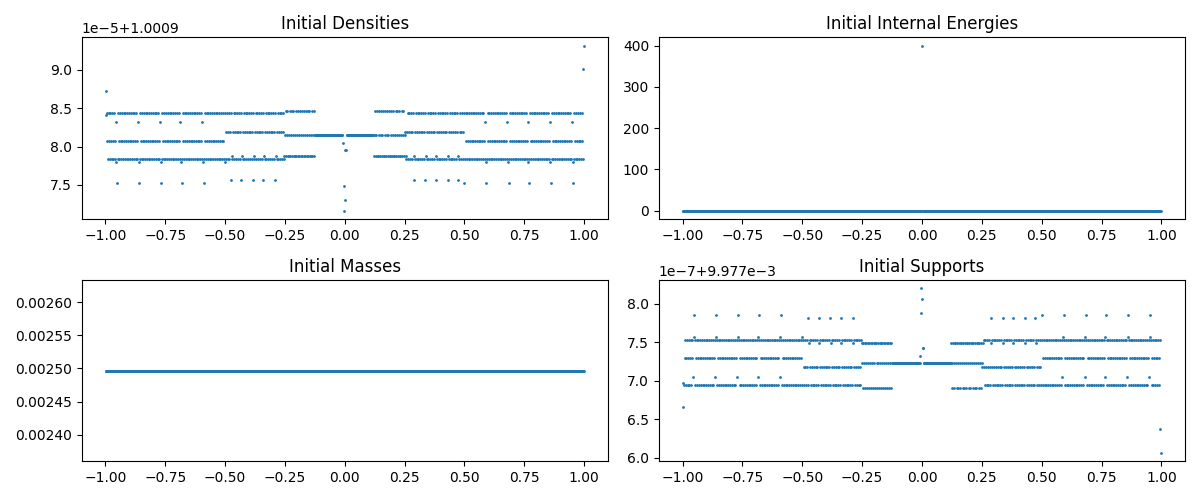

In [8]:
fig, axis = plt.subplots(2,2, figsize = (12, 5), squeeze = False)
plotToAxis1D(axis[0,0], compSystem.state.positions, compSystem.state.densities, title = 'Initial Densities')
plotToAxis1D(axis[1,0], compSystem.state.positions, compSystem.state.masses, title = 'Initial Masses')
plotToAxis1D(axis[0,1], compSystem.state.positions, compSystem.state.internalEnergies, title = 'Initial Internal Energies')
plotToAxis1D(axis[1,1], compSystem.state.positions, compSystem.state.supports, title = 'Initial Supports')
fig.tight_layout()

In [9]:
update, adjacency, state = compressibleSPH_Monaghan(compSystem, config.dt, config, compressibleSPHConfig, verbose = True)

Module sphWarpCore.operations.wp_gradient f0134b6 load on device 'cuda:0' took 2.51 ms  (cached)
Module sphWarpCore.operations.wp_divergence 5883463 load on device 'cuda:0' took 3.13 ms  (cached)
Module compressibleSPH.modules.dissipation.wp_diffusion d5382fa load on device 'cuda:0' took 3.38 ms  (cached)
Module compressibleSPH.modules.dissipation.wp_conductivity 5e4ef65 load on device 'cuda:0' took 3.14 ms  (cached)
Module compressibleSPH.modules.dissipation.wp_dissipation 43957cd load on device 'cuda:0' took 3.48 ms  (cached)


In [ ]:
from compressibleSPH.systems.compSPH import CompSPHSystem, CompSPHState
from compressibleSPH.configurations.compSPHConfig import CompSPHConfig
from compressibleSPH.enumTypes import EnergyScheme

compSPHConfig = CompSPHConfig(
    gamma = gamma,
    rho0 = rho0,
    diffusionParams = diffusionParams,
    energyScheme = EnergyScheme.equalWork,
)

In [ ]:
from compressibleSPH.modules.adaptiveSupport import computeOmega

def compSPH_step(
    system: CompressibleSystem,
    dt: float,
    config: SimulationConfig,
    compParams: CompSPHConfig,
    verbose = False,
):

    currentSystem = compSystem#.initializeNewState()
    currentState = currentSystem.state

    rho_optimal, h_optimal, currentSystem.adjacency, *_ = evaluateOptimalSupport(currentState, config, SupportScheme.Gather, currentSystem.adjacency)
    currentState.supports = h_optimal
    currentState.densities = rho_optimal

    verletScale = 2 ** (1/config.dim)
    verletScale = 1

    adjacency = buildVerletList(
        currentState, 
        config.domain, verletScale = verletScale, supportMode = SupportScheme.SuperSymmetric,
        priorNeighborhood = currentSystem.adjacency,
        verbose = False)

    numNeighbors = adjacency.numNeighbors

    currentState.densities = warpOperation(
        currentState,
        OperationProperties(
            kernel = config.kernel,
            operation = WarpOperation.Density,
            supportMode = config.supportMode,
        ),
        domain = config.domain,
        adjacency = adjacency,
    )

    currentState.entropies, _, currentState.pressures, currentState.soundspeeds = idealGasEOS(
        A = None,
        u = currentState.internalEnergies,
        P = None,
        rho = currentState.densities,
        gamma = compressibleSPHConfig.gamma,
    )

    omega = computeOmega(currentState, 
            OperationProperties(
                kernel = config.kernel,
                supportMode = SupportScheme.Gather,
            ),
            domain = config.domain,
            adjacency = adjacency
    )

    gradHState = GradHState(
        queryOmegas = omega
    )

In [11]:
compSystem.state.pressures = torch.sin(currentState.positions[:,0] * np.pi) * 10 + 10
compSystem.state.velocities[:,0] = torch.cos(currentState.positions[:,0] * 4 * np.pi) * 10

In [12]:
from compressibleSPH.modules.compSPH.accel import computeCompSPHAccelWarp

dvdt, pressureAccel_ij, viscosityAccel_ij = computeCompSPHAccelWarp(
    queryParticles = compSystem.state,
    operationProperties = OperationProperties(
        kernel = config.kernel,
        supportMode = config.supportMode
    ),
    domain = config.domain,
    conductivityParams= compressibleSPHConfig.diffusionParams,

    queryEnergies = compSystem.state.internalEnergies,
    queryVelocities= compSystem.state.velocities,
    queryCs = compSystem.state.soundspeeds,
    queryAlphas = compSystem.state.alphas,
    queryPressures = compSystem.state.pressures,

    adjacency = adjacency,
    gradHState = gradHState
)
print(f'Max pressure acceleration: {pressureAccel_ij.abs().max()}')
print(f'Max viscosity acceleration: {viscosityAccel_ij.abs().max()}')
print(f'Max total acceleration: {(dvdt).abs().max()}')

Module compressibleSPH.modules.compSPH.accel f80cc06 load on device 'cuda:0' took 3.74 ms  (cached)
Max pressure acceleration: 2122.45166015625
Max viscosity acceleration: 9.74416446685791
Max total acceleration: 52.098602294921875


In [13]:
from compressibleSPH.modules.compSPH.dudt import computeCompSPHdudtWarp
dudt = computeCompSPHdudtWarp(
    queryParticles = compSystem.state,
    operationProperties = OperationProperties(
        kernel = config.kernel,
        supportMode = config.supportMode
    ),
    domain = config.domain,
    conductivityParams= compressibleSPHConfig.diffusionParams,

    queryEnergies = compSystem.state.internalEnergies,
    queryVelocities= compSystem.state.velocities,
    queryCs = compSystem.state.soundspeeds,
    queryAlphas = compSystem.state.alphas,
    queryPressures = compSystem.state.pressures,

    adjacency = adjacency,
    gradHState = gradHState
)
print(f'Max du/dt: {dudt.abs().max()}')

Module compressibleSPH.modules.compSPH.dudt b0f9905 load on device 'cuda:0' took 3.56 ms  (cached)
Max du/dt: 2416.285400390625


In [14]:
from compressibleSPH.modules.compSPH.balance import computeCompSPHBalanceTermWarp
from compressibleSPH.enumTypes import EnergyScheme

# energyScheme = EnergyScheme.equalWork

# f_ij = computeCompSPHBalanceTermWarp(
#     queryParticles = compSystem.state,
#     operationProperties = OperationProperties(
#         kernel = config.kernel,
#         supportMode = config.supportMode
#     ),
#     domain = config.domain,

#     queryEnergies = compSystem.state.internalEnergies,
#     queryVelocities= compSystem.state.velocities,
#     queryPressures = compSystem.state.pressures,

#     pairWise_pressureAccel= pressureAccel_ij,
#     pairWise_viscosityAccel = viscosityAccel_ij,
#     energyScheme = energyScheme,
#     dt=config.dt.detach().cpu().item(),
#     gamma = compressibleSPHConfig.gamma,

#     adjacency = adjacency,
#     gradHState = gradHState
# )

# f_ij

In [15]:
# from compressibleSPH.modules.pressure import computePressureForceSymmetric
# dvdt = computePressureForceSymmetric(
#     currentState,
#     config,
#     supportScheme = SupportScheme.KernelMeanSymmetric,
#     adjacency = adjacency,
#     gradH = gradHState
# )
# (dvdt - accel).abs().max()

In [16]:
from diffSPH.schemes.states.compressiblesph import CompressibleState as CompState
from diffSPH.kernels import getSPHKernelv2
from diffSPH.neighborhood import evaluateNeighborhood

from diffSPH.modules.compSPH import compSPH_acceleration, compSPH_dudt, compute_fij

diffSPHDiffusionConfig = {    
    'diffusion':{
        'C_l': 1,
        'C_q': 0,
        'Cu_l': 1,
        'Cu_q': 0,
        'monaghanSwitch': True,
        'viscosityTerm': 'Monaghan',
        'correctXi': True,
        
        'viscosityFormulation': 'Price2012_98',
        'thermalConductivityFormulation': 'Price2008',
        'signalTerm': 'Price2019',
        'K': 1.0,
        
        'thermalConductivity' : 0.5,
    },
    'diffusionSwitch':{
        'scheme': ViscositySwitch.NoneSwitch,
        'limitXi': False,
    },
    'domain': config.domain,
    'kernel': KernelType.Wendland2,
    'verbose': True,
}

diffSPHState = CompState(
    positions = currentState.positions,
    velocities = currentState.velocities,
    densities = currentState.densities,
    supports = currentState.supports,
    internalEnergies = currentState.internalEnergies,
    totalEnergies = currentState.totalEnergies,
    entropies = currentState.entropies,
    soundspeeds= currentState.soundspeeds,
    masses = currentState.masses,
    kinds = currentState.kinds,
    materials = currentState.materials,
    UIDs = currentState.UIDs,
    pressures = currentState.pressures,
    omega = gradHState.queryOmegas,
)

wrappedKernel = getSPHKernelv2(KernelType.Wendland2)
verletScale = 1
neighborhood, neighbors = evaluateNeighborhood(diffSPHState, config.domain, KernelType.Wendland2, verletScale = verletScale, mode = SupportScheme.SuperSymmetric, priorNeighborhood=None)


dvdt_dsph, ap_ij_dsph, av_ij_dsph = compSPH_acceleration(diffSPHState, wrappedKernel, neighbors.get('noghost'), SupportScheme.SuperSymmetric, diffSPHDiffusionConfig)

print(f'Max pressure acceleration: {ap_ij_dsph.abs().max()}')
print(f'Max viscosity acceleration: {av_ij_dsph.abs().max()}')
print(f'Max total acceleration: {(dvdt_dsph).abs().max()}')

dudt_dsph = compSPH_dudt(diffSPHState, wrappedKernel, neighbors.get('noghost'), SupportScheme.SuperSymmetric, diffSPHDiffusionConfig)

print(f'Max du/dt: {dudt_dsph.abs().max()}')

Max pressure acceleration: 2122.451171875
Max viscosity acceleration: 9.74416446685791
Max total acceleration: 52.09876251220703
Max du/dt: 2416.285888671875


In [26]:
from diffSPH.enums import EnergyScheme as EnergySchemeDiffSPH
v_halfstep = diffSPHState.velocities + 0.5 * config.dt * dvdt


energyScheme = EnergyScheme.CRK
print(f'Energy scheme: {energyScheme} [value: {energyScheme.value}]' )

f_ij = computeCompSPHBalanceTermWarp(
    queryParticles = compSystem.state,
    operationProperties = OperationProperties(
        kernel = config.kernel,
        supportMode = config.supportMode
    ),
    domain = config.domain,

    queryEnergies = compSystem.state.internalEnergies,
    queryVelocities= v_halfstep,
    queryPressures = compSystem.state.pressures,

    pairWise_pressureAccel= pressureAccel_ij,
    pairWise_viscosityAccel = viscosityAccel_ij,
    energyScheme = energyScheme,
    dt=config.dt.detach().cpu().item(),
    gamma = compressibleSPHConfig.gamma,

    adjacency = adjacency,
    gradHState = gradHState
)

# f_ij
print(f_ij)
print(f'Max f_ij: {f_ij.abs().max()}, Mean: {f_ij.mean()}, Min: {f_ij.min()}, Max: {f_ij.max()}')
print(f'Max deviation from 0.5: {(f_ij - 0.5).abs().max()}')

diffSPHDiffusionConfig['energyScheme'] = EnergySchemeDiffSPH.CRK
f_ij_dsph = compute_fij(diffSPHState, wrappedKernel, neighbors.get('noghost'), SupportScheme.SuperSymmetric, diffSPHDiffusionConfig, config.dt, v_halfstep, ap_ij_dsph, av_ij_dsph)
# print(f_ij_dsph)
print(f'Max f_ij (diffSPH): {f_ij_dsph.abs().max()}, Mean: {f_ij_dsph.mean()}, Min: {f_ij_dsph.min()}, Max: {f_ij_dsph.max()}')
print(f'Max deviation from 0.5 (diffSPH): {(f_ij_dsph - 0.5).abs().max()}')

print(f'Max difference in f_ij: {(f_ij - f_ij_dsph).abs().max()}')

Energy scheme: EnergyScheme.CRK [value: 5]
tensor([0.4942, 0.4961, 0.5020,  ..., 0.4980, 0.4961, 0.4941], device='cuda:0')
Max f_ij: 0.9941655993461609, Mean: 0.5, Min: 0.0058343675918877125, Max: 0.9941655993461609
Max deviation from 0.5: 0.4941656291484833
Max f_ij (diffSPH): 0.9941656589508057, Mean: 0.5, Min: 0.005834357813000679, Max: 0.9941656589508057
Max deviation from 0.5 (diffSPH): 0.49416565895080566
Max difference in f_ij: 1.0132789611816406e-06


In [19]:
print('Max pressure deviation:', (ap_ij_dsph - pressureAccel_ij).abs().max())
print('Max viscosity deviation:', (av_ij_dsph - viscosityAccel_ij).abs().max())
print('Max total acceleration deviation:', (dvdt_dsph - dvdt).abs().max())
print('Max du/dt deviation:', (dudt_dsph - dudt).abs().max())

Max pressure deviation: tensor(0.0005, device='cuda:0')
Max viscosity deviation: tensor(9.5367e-07, device='cuda:0')
Max total acceleration deviation: tensor(0.0011, device='cuda:0')
Max du/dt deviation: tensor(0.0078, device='cuda:0')


In [33]:
pressureAccel_ij
# viscosityAccel_ij

tensor([[  354.6518],
        [  945.7905],
        [ 1061.2377],
        ...,
        [-1061.2208],
        [ -938.4009],
        [ -349.1239]], device='cuda:0')

In [40]:
config.dt = 1e-4
t_limit = goalTime
nSteps = int(t_limit / config.dt)

print(f"Running with dt: {config.dt}, which gives nSteps: {nSteps}")
nSteps = 512

runningState = compSystem.initializeNewState()
for i in (tq := tqdm(range(nSteps), leave = True)):
    result = integrator.function(
        state = runningState,
        f = compressibleSPH_Monaghan,
        dt = config.dt,  
        config = config,
        compParams = compressibleSPHConfig,
        verbose = False,
    )

    runningState = result.state

Running with dt: 0.0001, which gives nSteps: 5556


  0%|          | 0/512 [00:00<?, ?it/s]

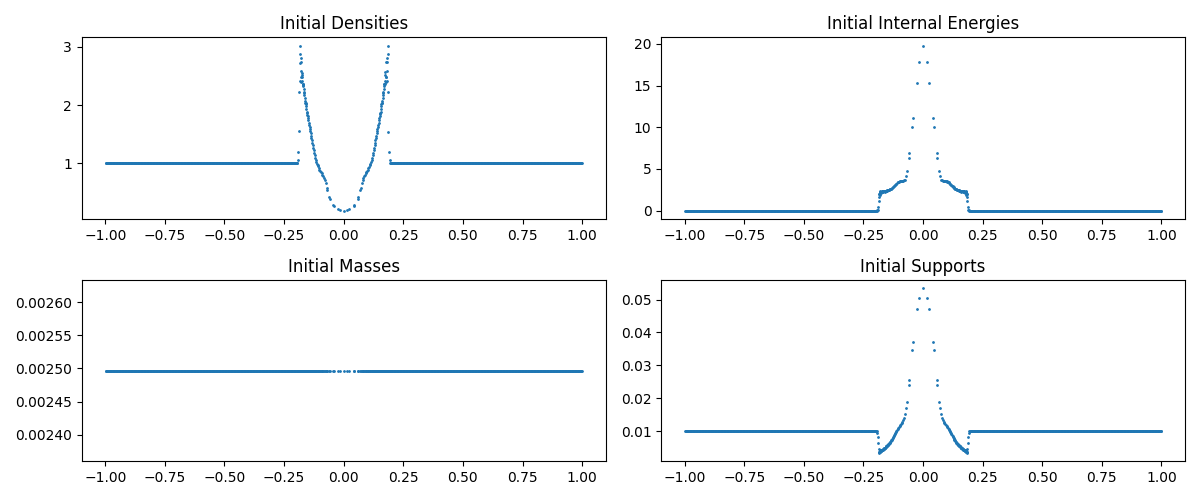

In [41]:
fig, axis = plt.subplots(2,2, figsize = (12, 5), squeeze = False)
plotToAxis1D(axis[0,0], runningState.state.positions, runningState.state.densities, title = 'Initial Densities')
plotToAxis1D(axis[1,0], runningState.state.positions, runningState.state.masses, title = 'Initial Masses')
plotToAxis1D(axis[0,1], runningState.state.positions, runningState.state.internalEnergies, title = 'Initial Internal Energies')
plotToAxis1D(axis[1,1], runningState.state.positions, runningState.state.supports, title = 'Initial Supports')
fig.tight_layout()

Adjusted time for plotting: 0.05120000000000044
tensor(0.0914, device='cuda:0')


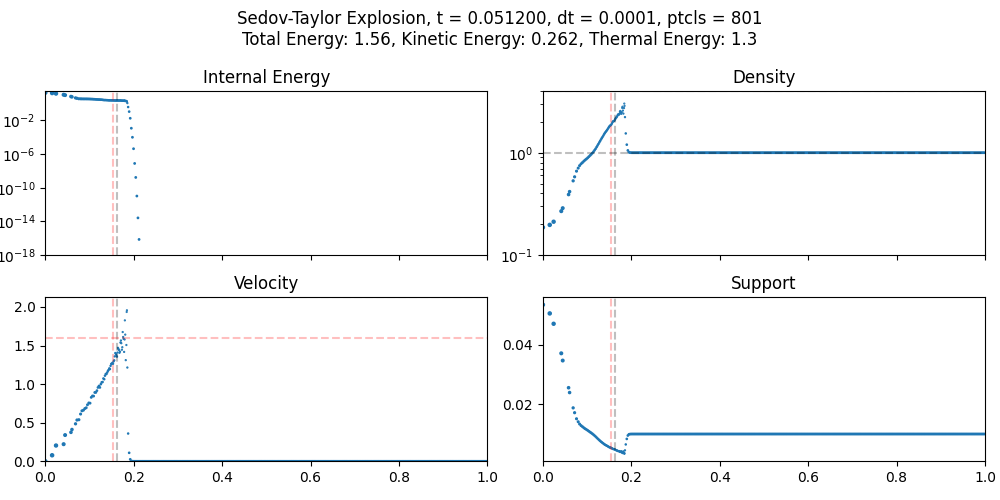

In [42]:
fig, axis = plt.subplots(2, 2, figsize=(10, 5), squeeze=False, sharex=True, sharey=False)

axis[0,0].scatter(runningState.state.positions.cpu().numpy(), runningState.state.internalEnergies.cpu().numpy(), s = runningState.state.supports.cpu().numpy() * 100)
axis[0,1].scatter(runningState.state.positions.cpu().numpy(), runningState.state.densities.cpu().numpy(), s = runningState.state.supports.cpu().numpy() * 100)
axis[1,0].scatter(runningState.state.positions.cpu().numpy(), runningState.state.velocities.cpu().numpy(), s = runningState.state.supports.cpu().numpy() * 100)
axis[1,1].scatter(runningState.state.positions.cpu().numpy(), runningState.state.supports.cpu().numpy(), s = runningState.state.supports.cpu().numpy() * 100)

axis[0,0].set_title('Internal Energy')
axis[0,1].set_title('Density')
axis[1,0].set_title('Velocity')
axis[1,1].set_title('Support')

kineticEnergy = 0.5 * (torch.linalg.norm(runningState.state.velocities, dim = -1) **2 * runningState.state.masses).sum()
thermalEnergy = (runningState.state.internalEnergies * runningState.state.masses).sum()
totalEnergy = kineticEnergy + thermalEnergy

fig.suptitle(f'Sedov-Taylor Explosion, t = {runningState.t:2f}, dt = {config.dt:.3g}, ptcls = {len(runningState.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}')
fig.tight_layout()

# prefix = './images/sedov_1d_201_sharp/'
# os.makedirs(prefix, exist_ok = True)

rt = rad_t(runningState.t)
# vt = vel_t(runningState.t)
    
    
def setupPlot(axis, t):
    vs, r2, v2, rho2, P2 = answer.shockState(t)
    rt = rad_t(t)
    
    for ax in axis.flatten():
        ax.axvline(r2, color = 'black', linestyle = '--', alpha = 0.25)
        ax.axvline(-r2, color = 'black', linestyle = '--', alpha = 0.25)
        ax.axvline(rt, color = 'red', linestyle = '--', alpha = 0.25)
        ax.axvline(-rt, color = 'red', linestyle = '--', alpha = 0.25)
        
        
    # axis[1,0].axhline(vt, color = 'black', linestyle = '--', alpha = 0.25)
    axis[1,0].axhline(vs, color = 'black', linestyle = '--', alpha = 0.25)
    axis[1,0].axhline(-vs, color = 'black', linestyle = '--', alpha = 0.25)
    axis[1,0].axhline(v2, color = 'red', linestyle = '--', alpha = 0.25)
    axis[1,0].axhline(-v2, color = 'red', linestyle = '--', alpha = 0.25)
    axis[0,1].axhline(rho0, color = 'black', linestyle = '--', alpha = 0.25)
    axis[0,1].axhline(rho2, color = 'black', linestyle = '--', alpha = 0.25)

    axis[0,0].set_xlim(0, 1)
    axis[0,1].set_xlim(0, 1)
    axis[1,0].set_xlim(0, 1)
    axis[1,1].set_xlim(0, 1)

    axis[0,0].set_ylim(1e-18, 30)
    axis[0,1].set_ylim(0.1, 4)
    axis[1,0].set_ylim(0, vs)

    axis[0,0].set_yscale('log')
    axis[0,1].set_yscale('log')

t = runningState.t.cpu() if isinstance(runningState.t, torch.Tensor) else runningState.t
# t = t * initial_dt.cpu().item() / config.dt
print(f"Adjusted time for plotting: {t}")
print(initial_dt)
setupPlot(axis, t)

# fig.savefig(f'{prefix}/frame_{0:06d}.png')